In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,precision_score,recall_score,accuracy_score

In [3]:
df=pd.read_csv('loan_default_risk_dataset.csv')
df

,Retirement_Age,Debt_Amount,Monthly_Savings,Loan_Default_Risk
0,60.0,2996.52,2378.49,0
1,66.4,4137.23,1538.92,1
2,58.5,19865.75,2434.80,1
3,49.8,16855.70,2677.82,1
4,67.3,7902.37,2206.72,0
...,...,...,...,...
295,71.9,4393.93,2324.35,0
296,56.0,5861.44,1916.44,1
297,61.9,2503.60,2073.36,0
298,56.9,4754.51,2603.25,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Retirement_Age     300 non-null    float64
 1   Debt_Amount        299 non-null    float64
 2   Monthly_Savings    298 non-null    float64
 3   Loan_Default_Risk  300 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 9.5 KB


In [5]:
df.isnull().any()

Retirement_Age       False
Debt_Amount           True
Monthly_Savings       True
Loan_Default_Risk    False
dtype: bool

In [6]:
x=df.drop(columns='Loan_Default_Risk')
y=df['Loan_Default_Risk']

In [7]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

<Axes: >

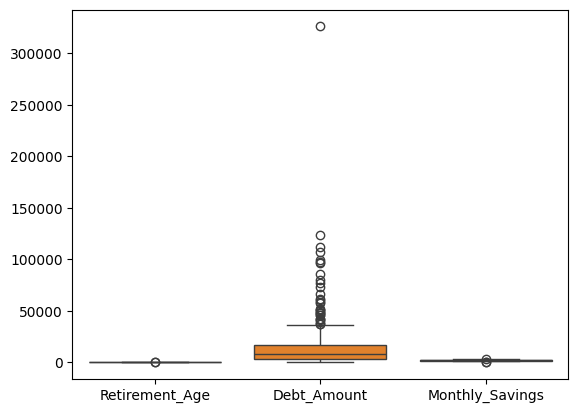

In [8]:
sns.boxplot(x)

In [9]:
num_pipeline1=Pipeline(
    steps=[
        ('simpute1',SimpleImputer(strategy='mean')),
        ('roscaling',RobustScaler())
    ]
)

In [10]:
num_pipeline2=Pipeline(
    steps=[
        ('simpute2',SimpleImputer(strategy='mean')),
        ('stdscaling',StandardScaler())
    ]
)

In [11]:
preprocessing=ColumnTransformer(
    transformers=[
        ('num_trans1',num_pipeline1,['Debt_Amount']),
        ('num_trans2',num_pipeline2,['Monthly_Savings']),
        ('stdscaler2',StandardScaler(),['Retirement_Age'])
    ]
)
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_trans1', ...), ('num_trans2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [12]:
main_pipeline=Pipeline(
    steps=[
        ('pre',preprocessing),
        ('model',LogisticRegression())
    ]
)

In [13]:
main_pipeline.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['Retirement_Age','Debt_Amount','Monthly_Savings']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_trans1', ...), ('num_trans2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining col

# Model Evaluation

**Confusion Matrix**

In [14]:
ytrain_predict=main_pipeline.predict(xtrain)
ytest_predict=main_pipeline.predict(xtest)

In [15]:
cm_train=confusion_matrix(ytrain,ytrain_predict)
cm_train

array([[119,   0],
       [  0, 121]])

In [16]:
cm_test=confusion_matrix(ytest,ytest_predict)
cm_test

array([[31,  0],
       [ 1, 28]])

**Conclusion**

**Train Data**

Out of 121 (1) labels 121 labels are correctly predicted as (1).

Out of 121 (1) labels 0 labels are wrongly predicted as (0).

Out of 119 (0) labels 119 labels are correctly predicted as (0).

Out of 119 (0) labels 0 labels are wrongly predicted as (1).

**Test Data**

Out of 28 (1) labels 28 labels are correctly predicted as (1).

Out of 28 (1) labels 0 labels are correctly predicted as (0).

Out of 32 (0) labels 31 labels are correctly predicted as (0).

Out of 32 (0) labels 1 labels are wrongly predicted as (1).

**Precision Score**

**Precision score for risk labels**

In [17]:
precision_score(ytrain,ytrain_predict,pos_label=1)

1.0

In [18]:
precision_score(ytest,ytest_predict,pos_label=1)

1.0

In [19]:
cm_train[:,1].sum()

np.int64(121)

In [20]:
cm_test[:,1].sum()

np.int64(28)

**Conclusion**

**Train Data**

Out of 121 (1) labels 100% labels are correctly predicted as (1).

Out of 121 (1) labels 0% labels are wrongly predicted as (1).
**Test Data**

Out of 28 (1) labels 100% labels are correctly predicted as (1).

Out of 28 (1) labels 0% labels are correctly predicted as (1).

**Precision score for not risk labels**

In [21]:
precision_score(ytrain,ytrain_predict,pos_label=0)

1.0

In [22]:
cm_train[:,0].sum()

np.int64(119)

In [23]:
precision_score(ytest,ytest_predict,pos_label=0)

0.96875

In [24]:
cm_test[:,0].sum()

np.int64(32)

**Conclusion**

**Train Data**

Out of 119 (0) labels 100% labels are correctly predicted as (0).

Out of 119 (0) labels 0% labels are wrongly predicted as (1).

**Test Data**

Out of 32 (0) labels 96% labels are correctly predicted as (0).

Out of 32 (0) labels 4% labels are wrongly predicted as (1).



**Recall score**

**Recall Score for risk labels**

In [25]:
recall_score(ytrain,ytrain_predict,pos_label=1)

1.0

In [26]:
recall_score(ytest,ytest_predict,pos_label=1)

0.9655172413793104

In [27]:
ytrain.value_counts()

Loan_Default_Risk
1    121
0    119
Name: count, dtype: int64

In [28]:
ytest.value_counts()

Loan_Default_Risk
0    31
1    29
Name: count, dtype: int64

**Conclusion**

**Train Data**

Out of 121 (1) labels 100% labels are correctly predicted as (1).

Out of 121 (1) labels 0% labels are wrongly predicted as (0).

**Test Data**

Out of 28 (1) labels 96% labels are correctly predicted as (1).

Out of 28 (1) labels 4% labels are wrongly predicted as (0).

**Recall score for not risk label**

In [29]:
recall_score(ytrain,ytrain_predict,pos_label=0)

1.0

In [30]:
recall_score(ytest,ytest_predict,pos_label=0)

1.0

**Conclusion**

**Train Data**

Out of 119 (0) labels 100% labels are correctly predicted as (0).

Out of 119 (0) labels 0% labels are wrongly predicted as (0).

**Test Data**

Out of 31 (0) labels 100% labels are correctly predicted as (0).

Out of 31 (0) labels 0% labels are wrongly predicted as (1).



**Accuracy score**

In [31]:
df['Loan_Default_Risk'].value_counts()

Loan_Default_Risk
0    150
1    150
Name: count, dtype: int64

**Accuracy score for risk labels**

In [32]:
accuracy_score(ytrain,ytrain_predict)

1.0

In [33]:
accuracy_score(ytest,ytest_predict)

0.9833333333333333

In [34]:
ytrain.value_counts().sum()

np.int64(240)

In [35]:
ytest.value_counts().sum()

np.int64(60)

**Conclusion**

**Train Data**

Out of 240 (1) labels 100% labels are correctly predicted as (1).

Out of 240 (0) labels 0% labels are wrongly predicted as (0).

**Test Data**

Out of 60 (1) labels 98% labels are correctly predicted as (1).

Out of 60 (0) labels 2% labels are correctly predicted as (0).
